## Exercise 1.4 Hotdog -- no hotdog
This is the poster hand-in project for the course. Please see the associated PDF for instructions.

In [1]:
import os
import numpy as np
import glob
import PIL.Image as Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

We always check that we are running on a GPU

In [2]:
if torch.backends.mps.is_available():
    print("The code will run on GPU using MPS.")
elif torch.cuda.is_available():
    print("The code will run on GPU using CUDA.")
else:
    print("The code will run on CPU.")

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

The code will run on GPU using MPS.
Using device: mps


We provide you with a class that can load the *hotdog/not hotdog* dataset you should use from /dtu/datasets1/02516/

In [3]:
class Hotdog_NotHotdog(torch.utils.data.Dataset):
    def __init__(self, train, transform, data_path='.'):
        self.transform = transform

        # Select train or test folder
        data_path = os.path.join(
            data_path,
            'train' if train else 'test'
        )

        # Find class folders
        image_classes = [
            os.path.split(d)[1]
            for d in glob.glob(data_path + '/*')
            if os.path.isdir(d)
        ]

        image_classes.sort()

        self.name_to_label = {
            c: i for i, c in enumerate(image_classes)
        }

        # Find images
        self.image_paths = []

        for extension in ['*.jpg', '*.jpeg', '*.png',
                          '*.JPG', '*.JPEG', '*.PNG']:
            self.image_paths.extend(
                glob.glob(data_path + '/*/' + extension)
            )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]

        image = Image.open(image_path).convert("RGB")

        # Get class name from folder name
        c = os.path.split(
            os.path.split(image_path)[0]
        )[1]

        y = self.name_to_label[c]

        X = self.transform(image)

        return X, y

Below is the simple way of converting the images to something that can be fed through a network.
Feel free to use something other than $128\times128$ images.

In [4]:
size = 128

train_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor()
])

batch_size = 64

# Automatically find the dataset location
if os.path.isdir("./train") and os.path.isdir("./test"):
    data_path = "."
elif os.path.isdir("./hotdog_nothotdog/train") and os.path.isdir("./hotdog_nothotdog/test"):
    data_path = "./hotdog_nothotdog"
else:
    raise FileNotFoundError(
        "Could not find the train/test folders. "
        "Make sure the notebook is in the correct folder."
    )

print("Dataset path:", os.path.abspath(data_path))

# Create datasets
trainset = Hotdog_NotHotdog(
    train=True,
    transform=train_transform,
    data_path=data_path
)

testset = Hotdog_NotHotdog(
    train=False,
    transform=test_transform,
    data_path=data_path
)

# Check dataset size BEFORE creating DataLoader
print("Training samples:", len(trainset))
print("Testing samples:", len(testset))

# Create DataLoaders
train_loader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("DataLoaders created successfully!")

Dataset path: /Users/susee/Downloads/hotdog_nothotdog
Training samples: 2047
Testing samples: 1862
DataLoaders created successfully!


Let's look at some images from our data 

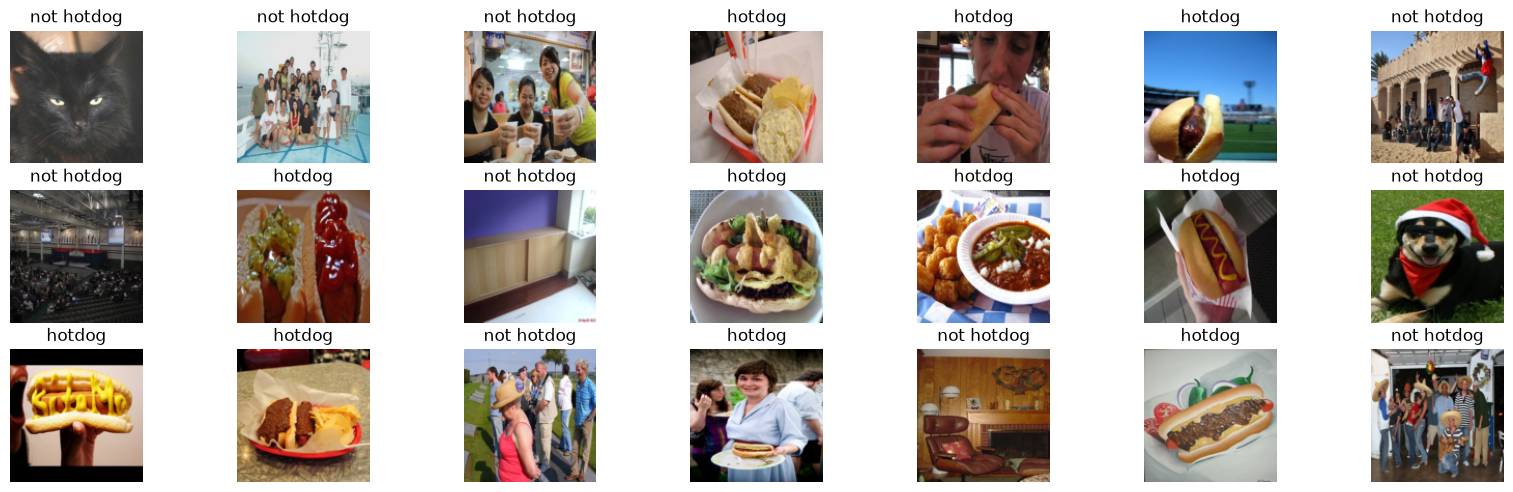

In [5]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(20,10))

for i in range(21):
    plt.subplot(5,7,i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i].numpy(), 0, 2), 0, 1))
    plt.title(['hotdog', 'not hotdog'][labels[i].item()])
    plt.axis('off')


Now create a model and train it!


Using best hyperparameters:
Optimizer: Adam
Learning rate: 0.001
Weight decay: 0.0001
Epoch 1/10 | Train loss: 1.8331 | Train accuracy: 0.5310
Epoch 2/10 | Train loss: 0.6177 | Train accuracy: 0.6869
Epoch 3/10 | Train loss: 0.5383 | Train accuracy: 0.7435
Epoch 4/10 | Train loss: 0.5251 | Train accuracy: 0.7465
Epoch 5/10 | Train loss: 0.4898 | Train accuracy: 0.7596
Epoch 6/10 | Train loss: 0.4903 | Train accuracy: 0.7719
Epoch 7/10 | Train loss: 0.4690 | Train accuracy: 0.7816
Epoch 8/10 | Train loss: 0.4525 | Train accuracy: 0.7880
Epoch 9/10 | Train loss: 0.4435 | Train accuracy: 0.7948
Epoch 10/10 | Train loss: 0.4516 | Train accuracy: 0.7997

FINAL RESULTS WITH DATA AUGMENTATION + BATCH NORMALIZATION
Final train loss:     0.4516
Final train accuracy: 0.7997
Test loss:            0.5192
Test accuracy:        0.7395

Confusion Matrix:
[[807  88]
 [397 570]]


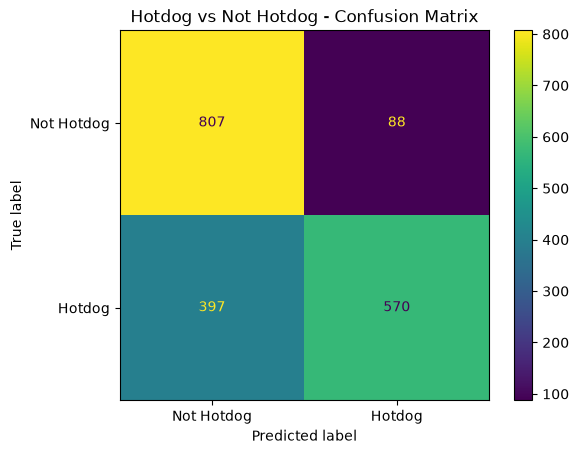

In [10]:
import torch
import torch.nn as nn
import numpy as np
import os

from torch.utils.data import DataLoader
from torchvision import transforms

# For confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# =========================================================
# DATA AUGMENTATION
# =========================================================

size = 128

train_transform = transforms.Compose([
    transforms.Resize((size, size)),

    # Data augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    # Gaussian Blur
    transforms.RandomApply(
        [
            transforms.GaussianBlur(
                kernel_size=3,
                sigma=(0.1, 2.0)
            )
        ],
        p=0.5
    ),

    transforms.ToTensor()
])


# NO augmentation for test data
test_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor()
])


# =========================================================
# DATASET
# =========================================================

trainset = Hotdog_NotHotdog(
    train=True,
    transform=train_transform,
    data_path="."
)

testset = Hotdog_NotHotdog(
    train=False,
    transform=test_transform,
    data_path="."
)


batch_size = 64

train_loader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)


# =========================================================
# CNN MODEL
# =========================================================

class Classifier(nn.Module):
    def __init__(self):
        super().__init__()

        self._model = nn.Sequential(

            # 1st Convolutional layer
            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),


            # 2nd Convolutional layer
            nn.Dropout(0.25),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),
            nn.BatchNorm2d(64),

            # 3rd Convolutional layer
            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            # Dense layer
            nn.Dropout(0.25),
            nn.Flatten(),

            # 128 x 16 x 16 = 32768
            nn.Linear(
                128 * 16 * 16,
                128
            ),
            nn.ReLU(),

            # Classification layer
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self._model(x)


# =========================================================
# BEST HYPERPARAMETERS
# =========================================================

learning_rate = 0.001
weight_decay = 0.0001
num_epochs = 10

print("Using best hyperparameters:")
print("Optimizer: Adam")
print("Learning rate:", learning_rate)
print("Weight decay:", weight_decay)


# =========================================================
# CREATE MODEL
# =========================================================

model = Classifier().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)


# =========================================================
# TRAINING
# =========================================================

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train loss: {epoch_loss:.4f} | "
        f"Train accuracy: {epoch_accuracy:.4f}"
    )


# =========================================================
# TEST EVALUATION
# =========================================================

model.eval()

test_running_loss = 0.0
test_correct = 0
test_total = 0

# Store predictions and true labels
all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        test_correct += (predictions == labels).sum().item()
        test_total += labels.size(0)

        # Save predictions and labels
        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )


test_loss = test_running_loss / test_total
test_accuracy = test_correct / test_total


# =========================================================
# FINAL RESULTS
# =========================================================

print("\n" + "=" * 50)
print("FINAL RESULTS WITH DATA AUGMENTATION + BATCH NORMALIZATION")
print("=" * 50)

print(f"Final train loss:     {epoch_loss:.4f}")
print(f"Final train accuracy: {epoch_accuracy:.4f}")
print(f"Test loss:            {test_loss:.4f}")
print(f"Test accuracy:        {test_accuracy:.4f}")


# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("\nConfusion Matrix:")
print(cm)


# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Hotdog", "Hotdog"]
)

disp.plot()

plt.title("Hotdog vs Not Hotdog - Confusion Matrix")
plt.show()